In [ ]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import vgg19

In [ ]:
print(tf.__version__)

2.17.1


**Load images**

In [ ]:
import gdown

In [ ]:
gdown.download('https://drive.google.com/uc?export=download&id=1tBE1PQ1AT6lFdHULVdyjbiVvn5r-zSuV', 'paris.jpg', quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=1tBE1PQ1AT6lFdHULVdyjbiVvn5r-zSuV
To: /content/paris.jpg
100%|██████████| 102k/102k [00:00<00:00, 51.1MB/s]


'paris.jpg'

In [ ]:
gdown.download('https://drive.google.com/uc?export=download&id=1iG-EPri-OZntOSrL63r3rv-xBkdfCa7S', 'starrynight.jpg', quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=1iG-EPri-OZntOSrL63r3rv-xBkdfCa7S
To: /content/starrynight.jpg
100%|██████████| 936k/936k [00:00<00:00, 17.4MB/s]


'starrynight.jpg'

In [ ]:
fil_path = '/content'
imgparis = 'paris.jpg'
imgstarry = 'starrynight.jpg'

In [ ]:
imgcontent_path = os.path.join(fil_path, imgparis)
imgstyle_path = os.path.join(fil_path, imgstarry)

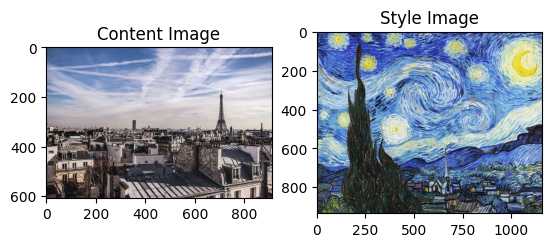

In [ ]:
input_content = cv.imread(imgcontent_path)
input_style = cv.imread(imgstyle_path)
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(input_content, cv.COLOR_BGR2RGB))
plt.title('Content Image')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(input_style, cv.COLOR_BGR2RGB))
plt.title('Style Image')
plt.show()

In [ ]:
# Generated image size
RESIZE_HEIGHT = 607

NUM_ITER = 3000

# Weights of the different loss components
CONTENT_WEIGHT = 8e-4 # 8e-4
STYLE_WEIGHT = 8e-1 # 8e-4

# The layer to use for the content loss.
CONTENT_LAYER_NAME = "block5_conv2" # "block2_conv2"

# List of layers to use for the style loss.
STYLE_LAYER_NAMES = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1",
]

In [ ]:
def get_result_image_size(image_path, result_height):
    image_width, image_height = keras.preprocessing.image.load_img(image_path).size
    result_width = int(image_width * result_height / image_height)
    return result_height, result_width

In [ ]:
def preprocess_image(image_path, target_height, target_width):
    img = keras.preprocessing.image.load_img(image_path, target_size = (target_height, target_width))
    arr = keras.preprocessing.image.img_to_array(img)
    arr = np.expand_dims(arr, axis = 0)
    arr = vgg19.preprocess_input(arr)
    return tf.convert_to_tensor(arr)

In [ ]:
def get_model():
    # Build a VGG19 model loaded with pre-trained ImageNet weights
    model = vgg19.VGG19(weights = 'imagenet', include_top = False)

    # Get the symbolic outputs of each "key" layer (we gave them unique names).
    outputs_dict = dict([(layer.name, layer.output) for layer in model.layers])

    # Set up a model that returns the activation values for every layer in VGG19 (as a dict).
    return keras.Model(inputs = model.inputs, outputs = outputs_dict)

In [ ]:
def get_optimizer():
    return keras.optimizers.Adam(
        keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate = 8.0, decay_steps = 445, decay_rate = 0.98
            # initial_learning_rate = 2.0, decay_steps = 376, decay_rate = 0.98
        )
    )

In [ ]:
def compute_loss(feature_extractor, combination_image, content_features, style_features):
    combination_features = feature_extractor(combination_image)
    loss_content = compute_content_loss(content_features, combination_features)
    loss_style = compute_style_loss(style_features, combination_features, combination_image.shape[1] * combination_image.shape[2])

    return CONTENT_WEIGHT * loss_content + STYLE_WEIGHT * loss_style

In [ ]:
# A loss function designed to maintain the 'content' of the original_image in the generated_image
def compute_content_loss(content_features, combination_features):
    original_image = content_features[CONTENT_LAYER_NAME]
    generated_image = combination_features[CONTENT_LAYER_NAME]

    return tf.reduce_sum(tf.square(generated_image - original_image)) / 2

In [ ]:
def compute_style_loss(style_features, combination_features, combination_size):
    loss_style = 0

    for layer_name in STYLE_LAYER_NAMES:
        style_feature = style_features[layer_name][0]
        combination_feature = combination_features[layer_name][0]
        loss_style += style_loss(style_feature, combination_feature, combination_size) / len(STYLE_LAYER_NAMES)

    return loss_style

In [ ]:
# The "style loss" is designed to maintain the style of the reference image in the generated image.
# It is based on the gram matrices (which capture style) of feature maps from the style reference image and from the generated image
def style_loss(style_features, combination_features, combination_size):
    S = gram_matrix(style_features)
    C = gram_matrix(combination_features)
    channels = style_features.shape[2]
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (combination_size ** 2))

In [ ]:
def gram_matrix(x):
   x = tf.transpose(x, (2, 0, 1))
   features = tf.reshape(x, (tf.shape(x)[0], -1))
   gram = tf.matmul(features, tf.transpose(features))
   return gram

In [ ]:
def save_result(generated_image, result_height, result_width, name):
    img = deprocess_image(generated_image, result_height, result_width)
    # Đường dẫn đến thư mục lưu kết quả trên Google Drive
    save_dir = '/content/drive/MyDrive/style_transfer_results_1'
    # Tạo thư mục nếu chưa tồn tại
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    # Tạo đường dẫn đầy đủ đến file kết quả
    save_path = os.path.join(save_dir, name)
    keras.preprocessing.image.save_img(save_path, img)

In [ ]:
# Util function to convert a tensor into a valid image
def deprocess_image(tensor, result_height, result_width):
    tensor = tensor.numpy()
    tensor = tensor.reshape((result_height, result_width, 3))

    # Remove zero-center by mean pixel
    tensor[:, :, 0] += 103.939
    tensor[:, :, 1] += 116.779
    tensor[:, :, 2] += 123.680

    # 'BGR'->'RGB'
    tensor = tensor[:, :, ::-1]
    return np.clip(tensor, 0, 255).astype("uint8")

In [ ]:
# Prepare content, stlye images
content_image_path = os.path.join(fil_path, imgparis)
style_image_path = os.path.join(fil_path,imgstarry)
result_height, result_width = get_result_image_size(content_image_path, RESIZE_HEIGHT)
print("result resolution: (%d, %d)" % (result_height, result_width))


result resolution: (607, 910)


In [ ]:
# Preprocessing
content_tensor = preprocess_image(content_image_path, result_height, result_width)
style_tensor = preprocess_image(style_image_path, result_height, result_width)
generated_image = tf.Variable(tf.random.uniform(style_tensor.shape, dtype=tf.dtypes.float32))
# generated_image = tf.Variable(preprocess_image(content_image_path, result_height, result_width))

In [ ]:
# Build model
model = get_model()
optimizer = get_optimizer()
print(model.summary())

content_features = model(content_tensor)
style_features = model(style_tensor)


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, None, None, 64)      │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, None, None, 64)      │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, None, None, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, None, None, 128)     │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, None, None, 128)     │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, None, None, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, None, None, 256)     │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, None, None, 256)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, None, None, 512)     │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
checkpoint_dir = '/content/drive/MyDrive/checkpoint'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Tạo checkpoint
loss_history = []
ckpt = tf.train.Checkpoint(generated_image=generated_image, optimizer=optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, directory=checkpoint_dir, max_to_keep=5)

In [ ]:
loss_history_path = '/content/drive/MyDrive/checkpoint/loss_history.npy'
if not os.path.exists(loss_history_path):
    print("Creating an empty loss_history file.")
    np.save(loss_history_path, np.array([]))  # Lưu file rỗng

In [ ]:
# Khôi phục từ checkpoint nếu có
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    loss_history = np.load(os.path.join(checkpoint_dir, "loss_history.npy")).tolist()
    print("Khôi phục từ checkpoint:", ckpt_manager.latest_checkpoint)
    start_iter = int(ckpt_manager.latest_checkpoint.split("-")[-1])
else:
    start_iter = 0

Khôi phục từ checkpoint: /content/drive/MyDrive/checkpoint/ckpt-2400


In [ ]:
start_iter

2400

In [ ]:
# Optimize result image
for iter in range(start_iter, NUM_ITER):
    with tf.GradientTape() as tape:
        loss = compute_loss(model, generated_image, content_features, style_features)
        loss_history.append(loss.numpy())  # Lưu giá trị loss vào danh sách

    grads = tape.gradient(loss, generated_image)

    print("iter: %4d, loss: %8.f" % (iter, loss))
    optimizer.apply_gradients([(grads, generated_image)])

    if (iter + 1) % 100 == 0:
        name = "generated_at_iteration_%d.png" % (iter + 1)
        save_result(generated_image, result_height, result_width, name)
        ckpt_save_path = ckpt_manager.save(checkpoint_number=iter + 1)
        print(f'Đã lưu checkpoint tại {ckpt_save_path}')
        # Lưu lịch sử loss vào file .npy
        np.save(os.path.join(checkpoint_dir, "loss_history.npy"), loss_history)


iter: 2400, loss:    35510
iter: 2401, loss:    34820
iter: 2402, loss:    33883
iter: 2403, loss:    33530
iter: 2404, loss:    33599
iter: 2405, loss:    33332
iter: 2406, loss:    33044
iter: 2407, loss:    32714
iter: 2408, loss:    32438
iter: 2409, loss:    32293
iter: 2410, loss:    32212
iter: 2411, loss:    32086
iter: 2412, loss:    31944
iter: 2413, loss:    31834
iter: 2414, loss:    31776
iter: 2415, loss:    31731
iter: 2416, loss:    31827
iter: 2417, loss:    32083
iter: 2418, loss:    32546
iter: 2419, loss:    32807
iter: 2420, loss:    32983
iter: 2421, loss:    32776
iter: 2422, loss:    32215
iter: 2423, loss:    31727
iter: 2424, loss:    31621
iter: 2425, loss:    31642
iter: 2426, loss:    31668
iter: 2427, loss:    31511
iter: 2428, loss:    31391
iter: 2429, loss:    31414
iter: 2430, loss:    31417
iter: 2431, loss:    31723
iter: 2432, loss:    32002
iter: 2433, loss:    32391
iter: 2434, loss:    32898
iter: 2435, loss:    33063
iter: 2436, loss:    33068
i

In [ ]:
try:
    loss_history = np.load(loss_history_path)
    print("Nội dung của loss_history.npy:")
    print(loss_history)
except FileNotFoundError:
    print(f"File không tồn tại: {loss_history_path}")

Nội dung của loss_history.npy:
[ 32699.7578125   32781.078125    33167.60546875  33797.40625
  34337.26953125  35245.2578125   36284.92578125  37585.81640625
  37436.453125    36804.98828125  35478.80078125  35050.578125
  35785.97265625  35654.05078125  34874.359375    34027.171875
  34088.61328125  33927.9609375   33966.61328125  33513.75
  33124.82421875  32968.5625      32922.15234375  32784.40625
  32718.35351562  32603.0546875   32893.48828125  33356.6484375
  34139.4609375   34938.2421875   35335.171875    35285.9609375
  35029.          35163.578125    35694.49609375  36393.89453125
  35505.84765625  34226.3984375   34206.921875    34336.19921875
  34403.5078125   33693.55859375  33324.1875      33274.7890625
  33232.8359375   33425.984375    33619.69140625  33906.890625
  34262.41796875  35064.40625     36337.03125     37608.234375
  38621.578125    37741.671875    36681.0859375   35034.58203125
  34853.4921875   35457.703125    35247.890625    34432.3203125
  33623.21875     

In [ ]:
name = "result_%d_%f_%f.png" % (NUM_ITER, CONTENT_WEIGHT, STYLE_WEIGHT)
save_result(generated_image, result_height, result_width, name)

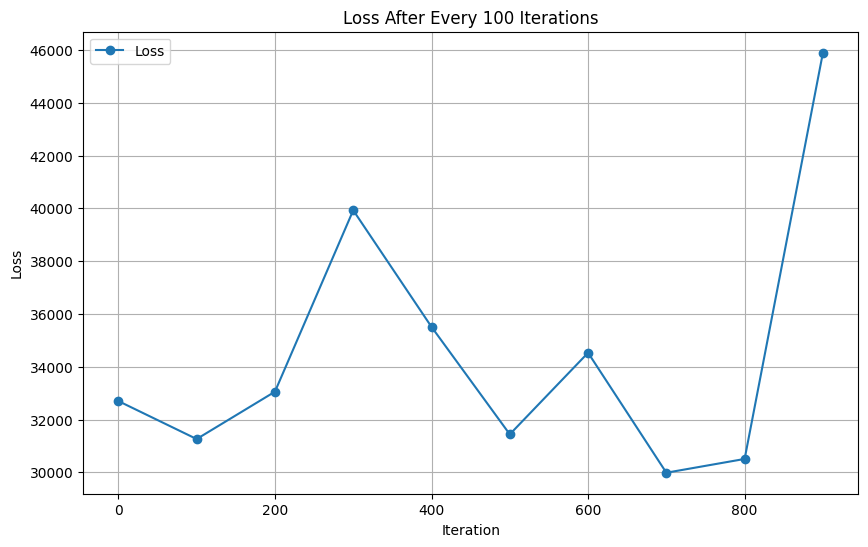

In [ ]:

loss_values = np.load('/content/drive/MyDrive/checkpoint/loss_history.npy')

interval = 100
sampled_losses = loss_values[::interval]  # Chọn mỗi phần tử thứ 100
iterations = np.arange(0, len(loss_values), interval)

plt.figure(figsize=(10, 6))
plt.plot(iterations, sampled_losses, marker='o', linestyle='-', label='Loss')
plt.title('Loss After Every 100 Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

***  
# Nội Dung:
## Tổng quát:
- **Input:** ảnh nội dung (content image) & ảnh phong cách (style image)
- **Ouput:** ảnh kết quả - sẽ là bức ảnh có nội dung đúng với ảnh nội dung nhưng lại đậm phong cách của ảnh phong cách
- **Ví dụ:**

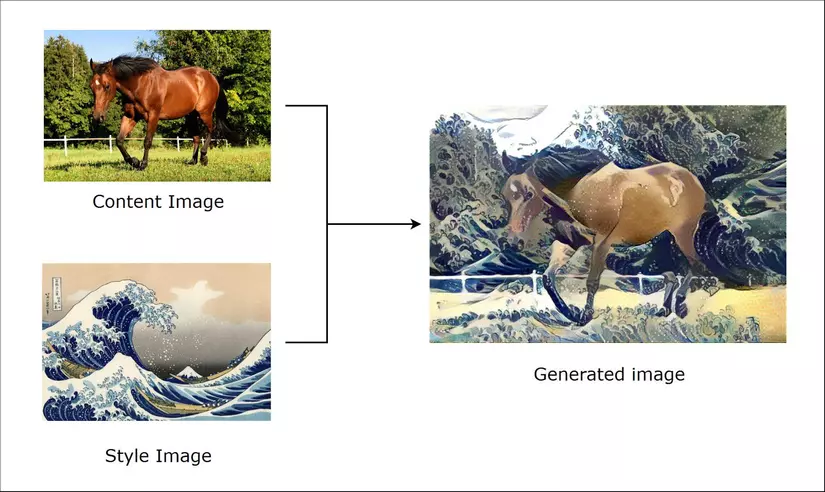



## Ý tưởng của bài toán:
- Chúng ta cũng sẽ sử dụng một mạng Convolution Neural Network (CNN) với mục đích phân tích ảnh và học các thuộc tính sâu (deep features) của ảnh, tuy nhiên khác với các bài toán khác, với Neural Style Transfer, chúng ta sẽ không cố gắng tối ưu mạng neural của chúng ta, thay vào đó, chúng ta sẽ cố gắng tối ưu trực tiếp đầu ra của mình (ảnh kết quả). Việc tối ưu của chúng ta sẽ dựa trên tối ưu tổng mất mát của:  
  1. Sự khác nhau giữa Ảnh nội dung với Ảnh kết quả (Content Image vs Generated Image)
  2. Sự khác nhau Ảnh phong cách với Ảnh kết quả (Style Image vs Generated Image)  
  3. Sự biến thiên của Ảnh kết quả (Variation of Generated Image)  
   
- Vậy nói cách khác, khi ảnh kết quả của chúng ta đạt được mất mát nhỏ nhất, điều này đồng nghĩa với việc nó chắc chắn sẽ giống với ảnh nội dung và ảnh phong cách. Tuỳ theo việc chúng ta khai báo hệ số cho các thành phần của hàm mất mát mà ảnh kết quả sẽ khác nhau.




## Khái quát về VGG19
- VGG là một mạng thần kinh tích chập (CNN) có độ sâu 19 lớp. Nó được xây dựng và đào tạo bởi Karen Simonyan và Andrew Zisserman tại Đại học Oxford vào năm 2014. Bạn có thể truy cập tất cả thông tin từ bài báo của họ, Very Deep Convolutional Networks for Large-Scale Image Recognition, được xuất bản vào năm 2015. VGG-19 được đào tạo bằng cách sử dụng hơn 1 triệu hình ảnh từ cơ sở dữ liệu ImageNet, trong đó có các ảnh màu 224×224 pixel. Đương nhiên, bạn có thể nhập vào mô hình các trọng số được huấn luyện bởi ImageNet. Điểm đặc biệt, VGG-19 có thể phân loại tới 1000 đối tượng.

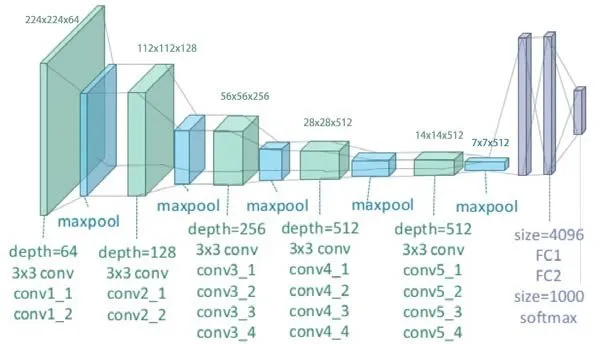

**Một số thông tin về VGG19:**  
1. **Kiến trúc:** VGG19 bao gồm 19 lớp có trọng số (weights):  
  - 16 lớp tích chập (convolutional layers).
  - 3 lớp kết nối đầy đủ (fully connected layers).
  - Các lớp phi tuyến (ReLU activation layers) và các lớp chuẩn hóa Batch Normalization để cải thiện hiệu năng.
  - Các lớp pooling được sử dụng sau một số lớp tích chập để giảm kích thước không gian (spatial dimensions).  
  
  **Kiến trúc chính:**
  - Đầu vào: Ảnh RGB kích thước 224 x 224 x 3.
  - Tích chập: Bộ lọc 3 x 3 (kernel size nhỏ để tập trung chi tiết).
  - Pooling: Lớp MaxPooling kích thước 2 x 2 để giảm kích thước.
  - Đầu ra: Lớp Softmax với 1000 nút cho 1000 lớp phân loại.  

2. **Đặc điểm chính:**  
  - Tăng độ chính xác: Nhờ các kernel nhỏ 3 x 3, mô hình đạt độ chính xác cao hơn so với các mô hình trước đó.
  - Hệ số tham số lớn: Khoảng 143 triệu tham số, yêu cầu tài nguyên tính toán lớn.  

3. **Ứng dụng:**
  - Tạo ảnh (Image Generation) và xử lý ảnh (Style Transfer).
  - Phân loại hình ảnh: Mô hình được huấn luyện trên bộ dữ liệu ImageNet (1 triệu ảnh với 1000 nhãn).  

4. **Ưu nhược điểm:**
  - Ưu điểm:
    - Đơn giản và hiệu quả: Cách thiết kế với kernel nhỏ 3 x 3 dễ hiểu và mạnh mẽ.  
    - Khả năng mở rộng: Dễ áp dụng vào nhiều bài toán thị giác máy tính khác nhau.  

  - Nhược điểm
    - Kích thước lớn: Nhiều tham số dẫn đến khó khăn khi triển khai trên thiết bị có tài nguyên hạn chế.  
    - Tốc độ: Tốn thời gian tính toán và bộ nhớ khi xử lý ảnh lớn.



## Thuật Toán  
**Loss function:**
- Để chuyển style của style image vào trong content image, chúng ta có thể định nghĩa hàm loss function như sau:  

  $  
L_{\text{total}}(\vec{p}, \vec{a}, \vec{x}) = \alpha L_{\text{content}}(\vec{p}, \vec{x}) + \beta L_{\text{style}}(\vec{a}, \vec{x})
  $  

  Trong đó:  
  - $\vec{p}$: Content image
  - $\vec{a}$: Style image
  - $\vec{x}$: generated image
  - Với $α$ và $β$ là các trọng số cho việc tái tạo nội dung và phong cách. $L_{\text{content}}$ thể hiện mức độ khác biệt giữa việc biểu diễn nội dung giữa $\vec{p}$ và $\vec{x}$. Trong khi đó $L_{\text{style}}$ biểu diễn mức độ khác biệt giữa $\vec{a}$ và $\vec{x}$.  

- Mục tiêu của bài toán là tìm ảnh $\vec{x}$ sao cho hàm $L_{\text{total}}$ này là nhỏ nhất.  

**$L_{content}$**  
- Công thức:  
$$
L_{\text{content}}(\vec{p}, \vec{x}, l) = \frac{1}{2} \sum_{i,j} \left( F_{ij}^l - P_{ij}^l \right)^2
$$  
Trong đó:
  - $P^l:$ biểu diễn đặc trưng của ảnh $\vec{p}$ trong lớp $l$  
  - $F^l:$ biểu diễn đặc trưng của ảnh $\vec{x}$ trong lớp $l$
  - Hình ảnh sẽ cố gắng được cập nhật sao cho cả hai hình ảnh có cùng giá trị biểu diễn nội dung (content representation). Khi sử dụng các lớp sâu hơn, thông tin pixel cụ thể sẽ bị mất, trong khi nếu sử dụng các lớp thấp hơn, kết quả nhận được sẽ tương tự như nội dung ban đầu. Dưới đây là một ví dụ về hình ảnh được tạo ra bằng cách sử dụng các giá trị kích hoạt (activation values) của `conv4_2` và `conv2_2`.


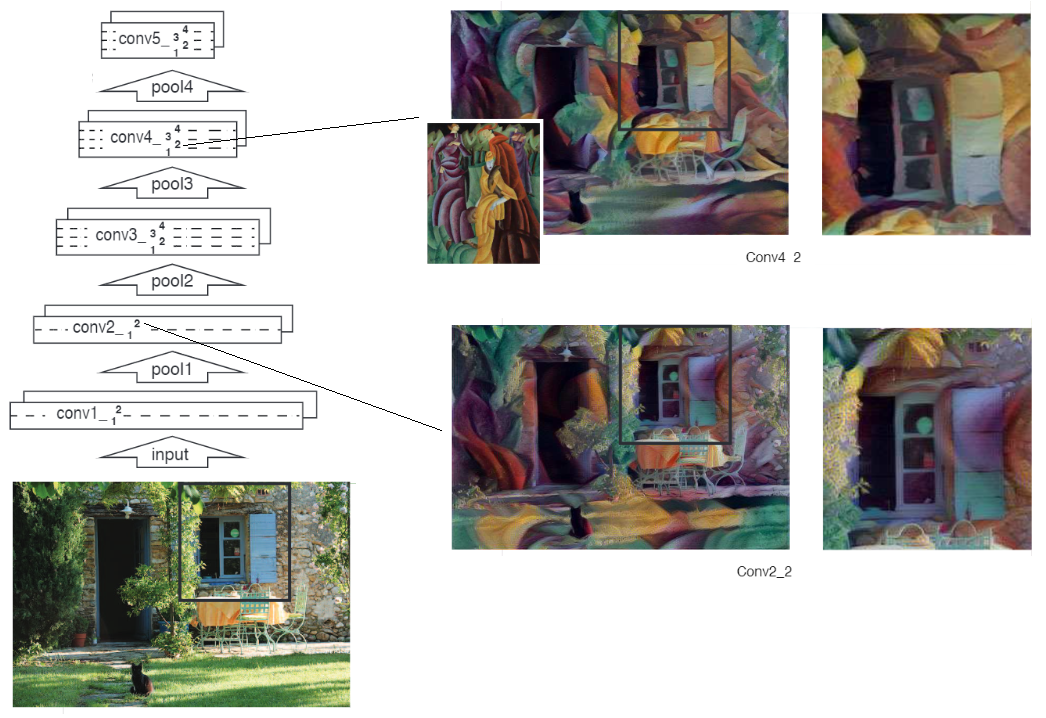

$L_{style}$  
Công thức:  
$$

$$